In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("customer_behavior.csv")
df.head()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


### 1.What is the average, median, and mode of PurchaseAmount?

In [10]:
mean_val=df['PurchaseAmount'].mean()
median_val=df['PurchaseAmount'].median()
mode_val=df['PurchaseAmount'].mode()[0]
print("mean value: ",mean_val)
print("median value: ",median_val)
print("mode value: ",mode_val)

mean value:  1003.9506701030928
median value:  998.0799999999999
mode value:  0.0


###  2.Are there any outliers in the PurchaseAmount data?

<Axes: ylabel='PurchaseAmount'>

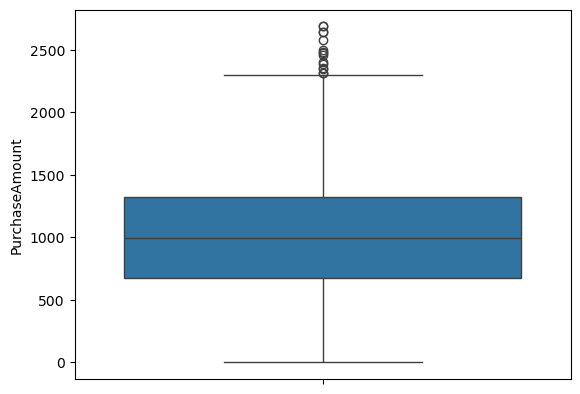

In [18]:
sns.boxplot(df["PurchaseAmount"])

#### yes, there are outliers in the PurchaseAmount column

### 3.Is there any skewness or kurtosis in the PurchaseAmount distribution?

In [19]:
df["PurchaseAmount"].skew()

np.float64(0.10609189374631554)

In [20]:
df["PurchaseAmount"].kurt()

np.float64(-0.2615105545319705)

### 4.Is there a significant difference in spending between male and female customers?

In [21]:
df.groupby('Gender')['PurchaseAmount'].mean()

Gender
Female     987.872046
Male      1019.176609
Name: PurchaseAmount, dtype: float64

In [24]:
df.isnull().sum()

CustomerID           0
Gender              97
Region             175
PurchaseAmount     150
ProductCategory    526
Churn              265
CampaignGroup      185
dtype: int64

In [34]:
data=df.dropna(subset=['Gender','PurchaseAmount'])

In [38]:
male=data[data['Gender']=='Male']['PurchaseAmount']
female=data[data['Gender']=='Female']['PurchaseAmount']
from scipy.stats import ttest_ind
t_stat, p_value = ttest_ind(male, female)
print("p-value:", p_value)

p-value: 0.025471167149519254


In [ ]:
#p-value is less than 0.5

### 6.Does PurchaseAmount vary significantly across different regions?

In [41]:
df['Region'].value_counts()

Region
South    1248
East     1226
North    1211
West     1140
Name: count, dtype: int64

In [43]:
df[['Region','PurchaseAmount']].isnull().sum()

Region            175
PurchaseAmount    150
dtype: int64

In [48]:
data=df.dropna(subset=['Region','PurchaseAmount'])

In [49]:
data[['Region','PurchaseAmount']].isnull().sum()

Region            0
PurchaseAmount    0
dtype: int64

In [51]:
from scipy.stats import f_oneway

groups = [group['PurchaseAmount'].values 
          for name, group in data.groupby('Region')]

f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 0.38966786354806704
p-value: 0.760452802731563


### 7.Which email campaign (A or B) performed better in terms of average PurchaseAmount?

In [52]:
df.groupby('CampaignGroup')['PurchaseAmount'].mean()

CampaignGroup
A    1011.945587
B     994.339965
Name: PurchaseAmount, dtype: float64

#### CampaignGroup A performed better

### 8.Can we assume PurchaseAmount follows a normal distribution?

In [53]:
df["PurchaseAmount"].skew()

np.float64(0.10609189374631554)

In [ ]:
#answer is YES

### 10.What is the 95% confidence interval for the average PurchaseAmount?

In [57]:
purchase = df['PurchaseAmount'].dropna()
mean = purchase.mean()
sem = stats.sem(purchase)
confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(purchase) - 1,
    loc=mean,
    scale=sem
)

print(mean)
print(confidence_interval)

1003.9506701030928
(np.float64(990.3789594609216), np.float64(1017.522380745264))
